# PREVISIONE POPOLARITÀ CANZONI
Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione e Contesto

### 1.1 Obiettivo del progetto

L'obiettivo del progetto è sviluppare un modello in grado di predire la popolarità di un brano musicale di Spotify a partire dalle sue caratteristiche audio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 1.2 Importazione del dataset
Il dataset utilizzato è il [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset), disponibile su Kaggle. Contiene circa 114.000 brani Spotify appartenenti a 114 generi musicali, con le seguenti informazioni:

**Metadati:**
- `track_id`: identificatore univoco del brano su Spotify
- `artists`: nomi degli artisti, separati da `;` in caso di collaborazioni
- `album_name`: nome dell'album
- `track_name`: titolo del brano
- `duration_ms`: durata del brano in millisecondi
- `explicit`: indica se il brano contiene contenuto esplicito (1 = sì, 0 = no)
- `track_genre`: genere musicale del brano
- `popularity`: valore compreso tra 0 e 100 che rappresenta la popolarità, calcolata in base al numero di ascolti recenti. Brani molto ascoltati di recente hanno score più alto rispetto a brani popolari in passato.

**Feature audio**:
- `danceability` (0–1): ballabilità del brano
- `energy` (0–1): intensità del brano
- `loudness` (dB): volume medio del brano
- `speechiness` (0–1): presenza di parlato; valori alti indicano brani prevalentemente parlati
- `acousticness` (0–1): probabilità che il brano sia acustico
- `instrumentalness` (0–1): probabilità che il brano non contenga voci
- `liveness` (0–1): presenza di pubblico nella registrazione; sopra 0.8 indica alta probabilità di live
- `valence` (0–1): positività emotiva dal brano; valori alti indicano un brano felice ed euforico, valori bassi un brano triste/malinconico
- `tempo` (BPM): velocità stimata in battiti per minuto
- `key` (0–11): tonalità del brano (0 = C, 1 = C#/Db, 2 = D, ecc...)
- `mode` (0/1): modalità della scala (1 = maggiore, 0 = minore)
- `time_signature` (3–7): numero di battiti per misura

`popularity`sarà la variabile target da predire.

In [2]:
import os.path
file = "dataset.csv";
if not os.path.exists(file):
    print("Missing dataset");

df = pd.read_csv(file, index_col=0);

df.info(verbose=False, memory_usage="deep");
df.head(1)

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), float64(9), int64(5), str(5)
memory usage: 48.8 MB


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


### 1.3 Pulizia iniziale dei dati
Prima di procedere con l’analisi dei dati, si effettua una prima fase di scrematura.

#### Rimozione colonne non informative

`track_id`: identificatore univoco di un brano, rimosso poichè non utile all'analisi.

In [3]:
df.drop(columns=["track_id"], inplace=True)

#### Rimozione valori nulli
Rimozione di eventuali righe con valori nulli.

In [4]:
df.isnull().sum()
df = df.dropna()

#### Rimozione brani con popularity = 0

In [5]:
len(df[df['popularity'] == 0])

16019

Si osserva che una parte consistente dei brani del dataset ha `popularity` = 0. Se non rimosse rischiano di distorcere l'analisi e la regressione.

In [6]:
df = df[df['popularity'] != 0]

#### Rimozione duplicati

In [7]:
n_duplicati = df.duplicated(subset=['track_name', 'artists']).sum()
print(f"Righe duplicate: {n_duplicati}")

Righe duplicate: 21395


Si osserva che il dataset contiene molte righe con stesso `track_name` e `artists` (stesso brano in più album). 
Questo è un problema, poichè inquinano il test set e distorcono l'analisi dei dati.

Conviene quindi aggregare dei brani con stesso nome e artisti, mantenendo solo la versione con `popularity` massima.

In [8]:
df = df.sort_values('popularity', ascending=False).drop_duplicates(subset=['track_name', 'artists'])

### 1.5 Conversioni e derivazioni
Conversione, per comodità, della durata dei brani da millisecondi a secondi.

In [9]:
df['duration_s'] = df['duration_ms'] / 1000
df = df.drop(columns=['duration_ms'])

Creazione della colonna `num_artists` (numero di artisti per ogni brano), potenzialmente rilevante per la popolarità: brani con più artisti tendono ad essere più popolari.

In [10]:
df['num_artists'] = df['artists'].astype(str).str.split(';').str.len()
df.head(1)

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s,num_artists
20001,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,False,0.714,0.472,2,-7.375,1,0.0864,0.013,0.000005,0.266,0.238,131.121,4,dance,156.943,2


#### Conversione delle stringhe in categorie

Le colonne testuali ad alta cardinalità (`track_genre`, `artists`, `album_name`) vengono convertite al dtype `category`.

In [11]:
for col in ['track_genre', 'artists', 'album_name']:
    df[col] = df[col].astype('category')

Con questa prima scrematura, la dimensione del dataset è stata ridotta significativamente.

In [12]:
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 76585 entries, 20001 to 60590
Columns: 20 entries, artists to num_artists
dtypes: bool(1), category(3), float64(10), int64(5), str(1)
memory usage: 20.7 MB


## 2. Analisi dei dati

### 2.1 Statistiche descrittive generali

In [13]:
print('tracks: \t' + str(len(df)))
print('artists:\t' + str(df['artists'].nunique()))
print('albums: \t' + str(df.groupby(['album_name', 'artists'], observed=True).ngroups))
print('genres: \t' + str(df['track_genre'].nunique()))

df.describe()

tracks: 	76585
artists:	29826
albums: 	53196
genres: 	114


,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_s,num_artists
count,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000,76585.000000
mean,37.439303,0.561695,0.640234,5.287263,-8.496698,0.633349,0.089653,0.322805,0.183126,0.221368,0.465632,122.416330,3.900268,231.499167,1.368036
std,17.837212,0.176131,0.255269,3.558216,5.187510,0.481893,0.118414,0.335335,0.330334,0.200116,0.262399,30.075551,0.450232,116.630574,0.881734
min,1.000000,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.266000,1.000000
25%,23.000000,0.450000,0.464000,2.000000,-10.327000,0.000000,0.036000,0.015000,0.000000,0.098700,0.246000,99.915000,4.000000,173.973000,1.000000
50%,37.000000,0.575000,0.682000,5.000000,-7.232000,1.000000,0.049200,0.184000,0.000085,0.133000,0.451000,122.369000,4.000000,215.689000,1.000000
75%,50.000000,0.691000,0.859000,8.000000,-5.130000,1.000000,0.087600,0.614000,0.144000,0.285000,0.677000,140.655000,4.000000,267.847000,1.000000
max,100.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,5237.295000,38.000000


Il dataset contiene quindi informazioni relative a 76585 brani, 29826 artisti, 53199 album e 114 generi.

### 2.2 Distribuzione delle feature
Di seguito vengono visualizzati alcuni istogrammi e statistiche per analizzare la distribuzione dei dati.

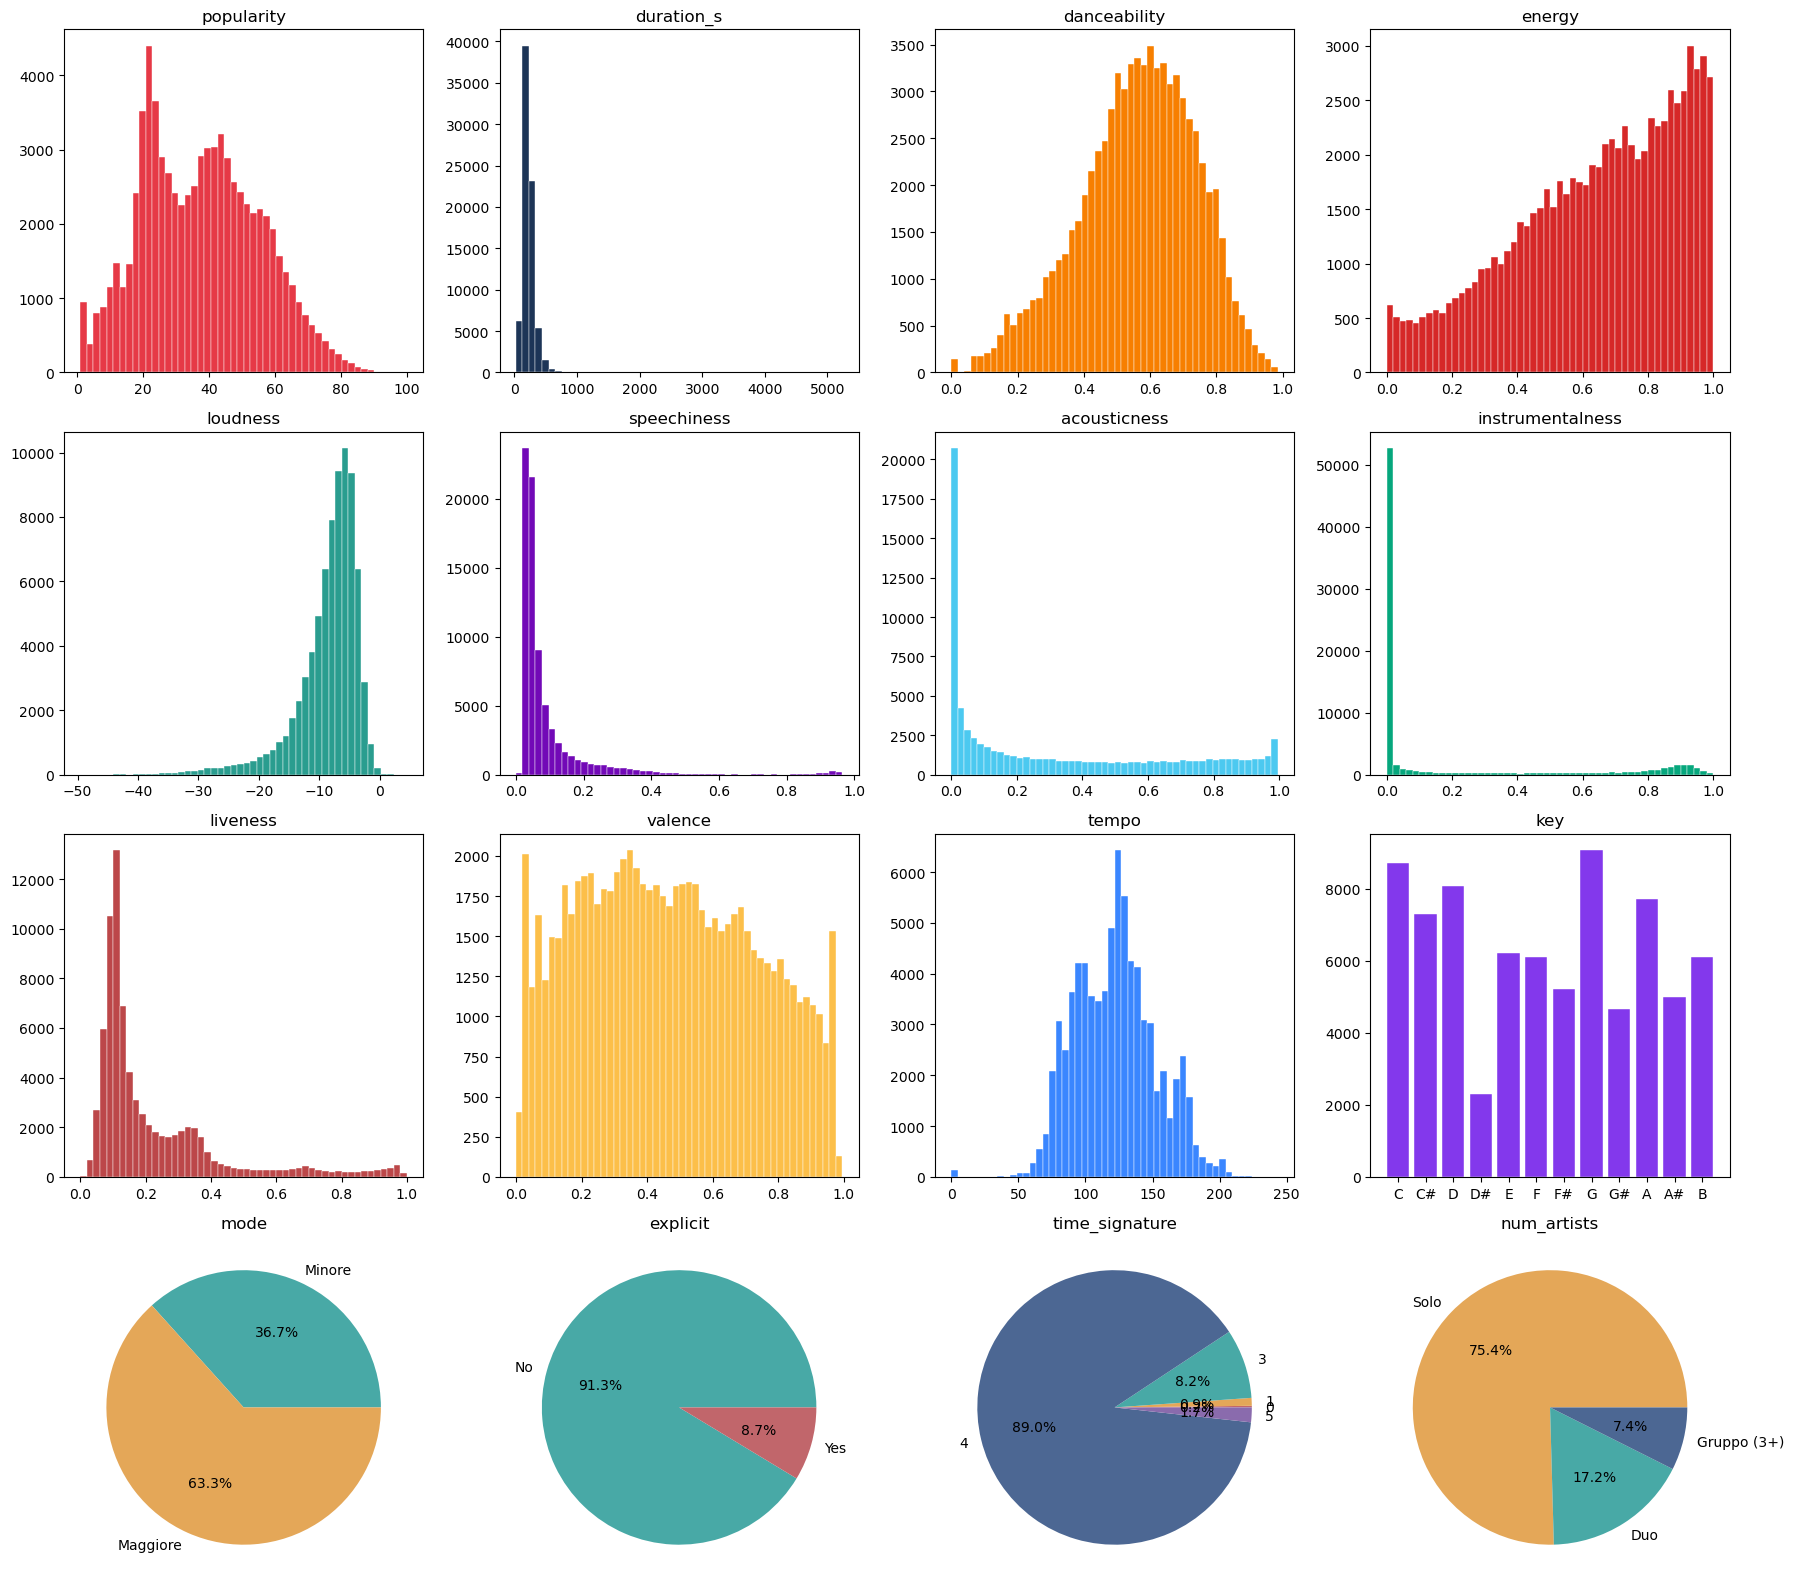

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

# Colori
feature_colors = {
    'popularity': '#E63946',
    'duration_s': '#1D3557',
    'danceability': '#F77F00',
    'energy': '#D62828',
    'loudness': '#2A9D8F',
    'speechiness': '#7209B7',
    'acousticness': '#4CC9F0',
    'instrumentalness': '#06A77D',
    'liveness': '#BC4749',
    'valence': '#FCBF49',
    'tempo': '#3A86FF',
    'key': '#8338EC',
}

# Feature continue (istogrammi)
continuous = [
    'popularity', 'duration_s', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo',
]

for i, feat in enumerate(continuous):
    data = df[feat]
    color = feature_colors[feat]
    axes[i].hist(data, bins=50, color=color, edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat)

idx = len(continuous)  # 11

# key — tutto dello stesso colore
key_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
key_counts = df['key'].value_counts().sort_index()
axes[idx].bar(
    [key_labels[int(k)] for k in key_counts.index],
    key_counts.values,
    color=feature_colors['key'],
    edgecolor='white', linewidth=0.3
)
axes[idx].set_title('key')
idx += 1

# mode — torta
mode_counts = df['mode'].value_counts().sort_index()
axes[idx].pie(
    mode_counts.values,
    labels=['Minore', 'Maggiore'],
    colors=['#48A9A6', '#E4A758'],
    autopct='%1.1f%%'
)
axes[idx].set_title('mode')
idx += 1

# explicit — torta
exp_counts = df['explicit'].value_counts().reindex([False, True], fill_value=0)
axes[idx].pie(
    exp_counts.values,
    labels=['No', 'Yes'],
    colors=['#48A9A6', '#C1666B'],
    autopct='%1.1f%%'
)
axes[idx].set_title('explicit')
idx += 1

# time_signature — torta
ts_counts = df['time_signature'].value_counts().sort_index()
axes[idx].pie(
    ts_counts.values,
    labels=[str(int(t)) for t in ts_counts.index],
    colors=['#C1666B', '#E4A758', '#48A9A6', '#4C6793', '#8A6BAD'],
    autopct='%1.1f%%'
)
axes[idx].set_title('time_signature')
idx += 1

# num_artists — torta
na = df['num_artists']
na_grouped = na.where(na <= 2, 3).value_counts().sort_index()
axes[idx].pie(
    na_grouped.values,
    labels=['Solo', 'Duo', 'Gruppo (3+)'],
    colors=['#E4A758', '#48A9A6', '#4C6793'],
    autopct='%1.1f%%'
)
axes[idx].set_title('num_artists')

plt.tight_layout()
plt.show()

Osservazioni principali sulle distribuzioni:

- `popularity` mostra una distribuzione asimmetrica con picco intorno a 20-40: la maggior parte dei brani ha popolarità medio-bassa.
- `duration_s` è fortemente concentrata intorno ai 200-250 secondi (3-4 minuti), il formato standard di un brano commerciale.
- `danceability` e `valence` hanno distribuzioni approssimativamente normali.
- `energy` è sbilanciata verso valori alti: la maggior parte dei brani nel dataset è energetica.
- `loudness` segue una distribuzione con picco intorno a -7 dB.
- `speechiness` e `liveness` sono fortemente concentrate su valori bassi: la maggior parte sono registrati in studio.
- in `instrumentalness` la maggioranza dei brani ha valore ≈ 0 (cantati), mentre una minoranza si concentra a valori alti (strumentali puri).
- `acousticness` è sbilanciata verso valori bassi: il dataset è dominato da produzioni elettroniche.
- `tempo` ha una distribuzione centrata intorno a 120 BPM.
- `key` è distribuita in modo relativamente uniforme tra le 12 tonalità, con leggera prevalenza di Do (C) e Sol (G).
- La maggioranza dei brani è in tonalità **maggiore**, **non esplicita**, in **4/4** e realizzata da un **artista solista**.

### 2.3 Correlazione tra le feature

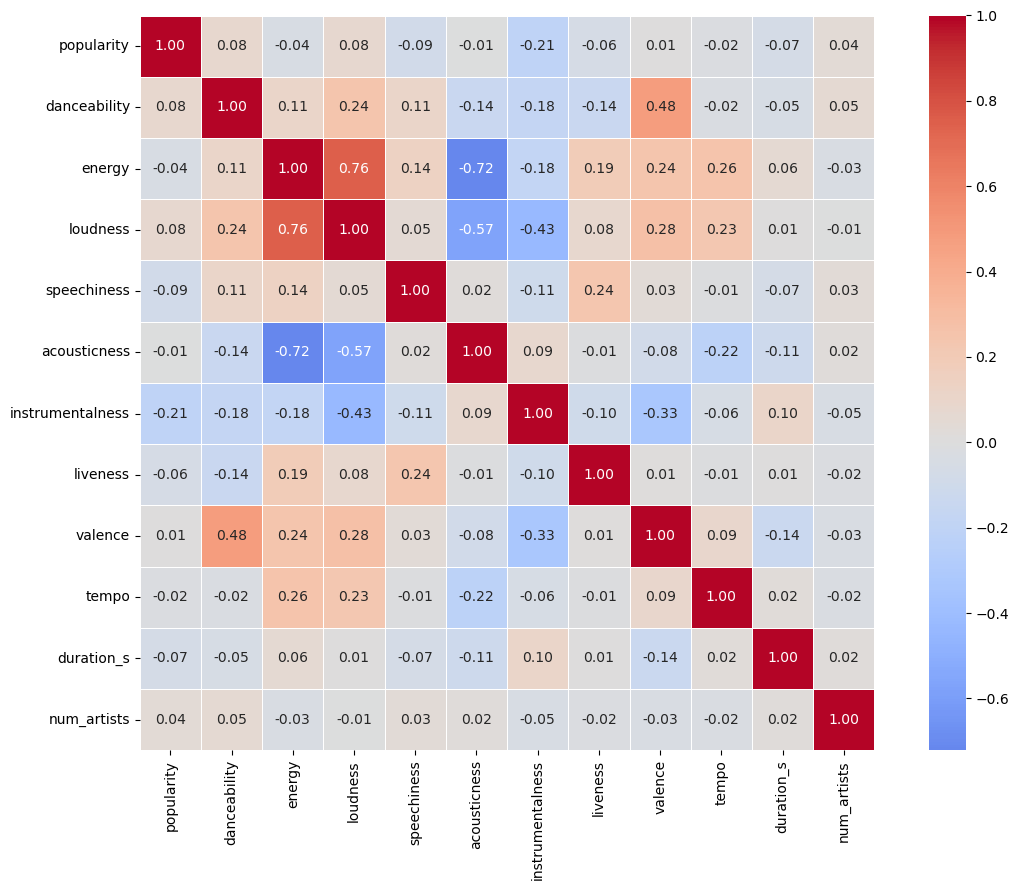

In [15]:
import seaborn as sns

numeric_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s', 'num_artists']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.tight_layout()
plt.show()

Dalla matrice di correlazione emergono alcune osservazioni rilevanti:

**Correlazioni con `popularity`:** nessuna feature audio presenta una correlazione forte con la variabile target. La più alta in valore assoluto è `instrumentalness` (-0.21): i brani strumentali tendono ad essere meno popolari. Seguono `speechiness` (-0.09), `danceability` e `loudness` (0.08). Le feature `energy`, `valence`, `tempo` e `num_artists` mostrano correlazioni praticamente nulle con la popolarità.

**Correlazioni tra feature:** si osservano alcune correlazioni forti tra le feature audio, indicative di ridondanza informativa:
- `energy` ↔ `loudness` (0.76): brani più energetici sono naturalmente più forti.
- `energy` ↔ `acousticness` (-0.72): brani acustici tendono ad avere energia più bassa.
- `loudness` ↔ `acousticness` (-0.57) e `loudness` ↔ `instrumentalness` (-0.43): i brani acustici e strumentali 
  sono tipicamente più silenziosi.
- `danceability` ↔ `valence` (0.48): i brani più ballabili trasmettono emozioni più positive.

### 2.4 Relazione tra feature audio e popularity

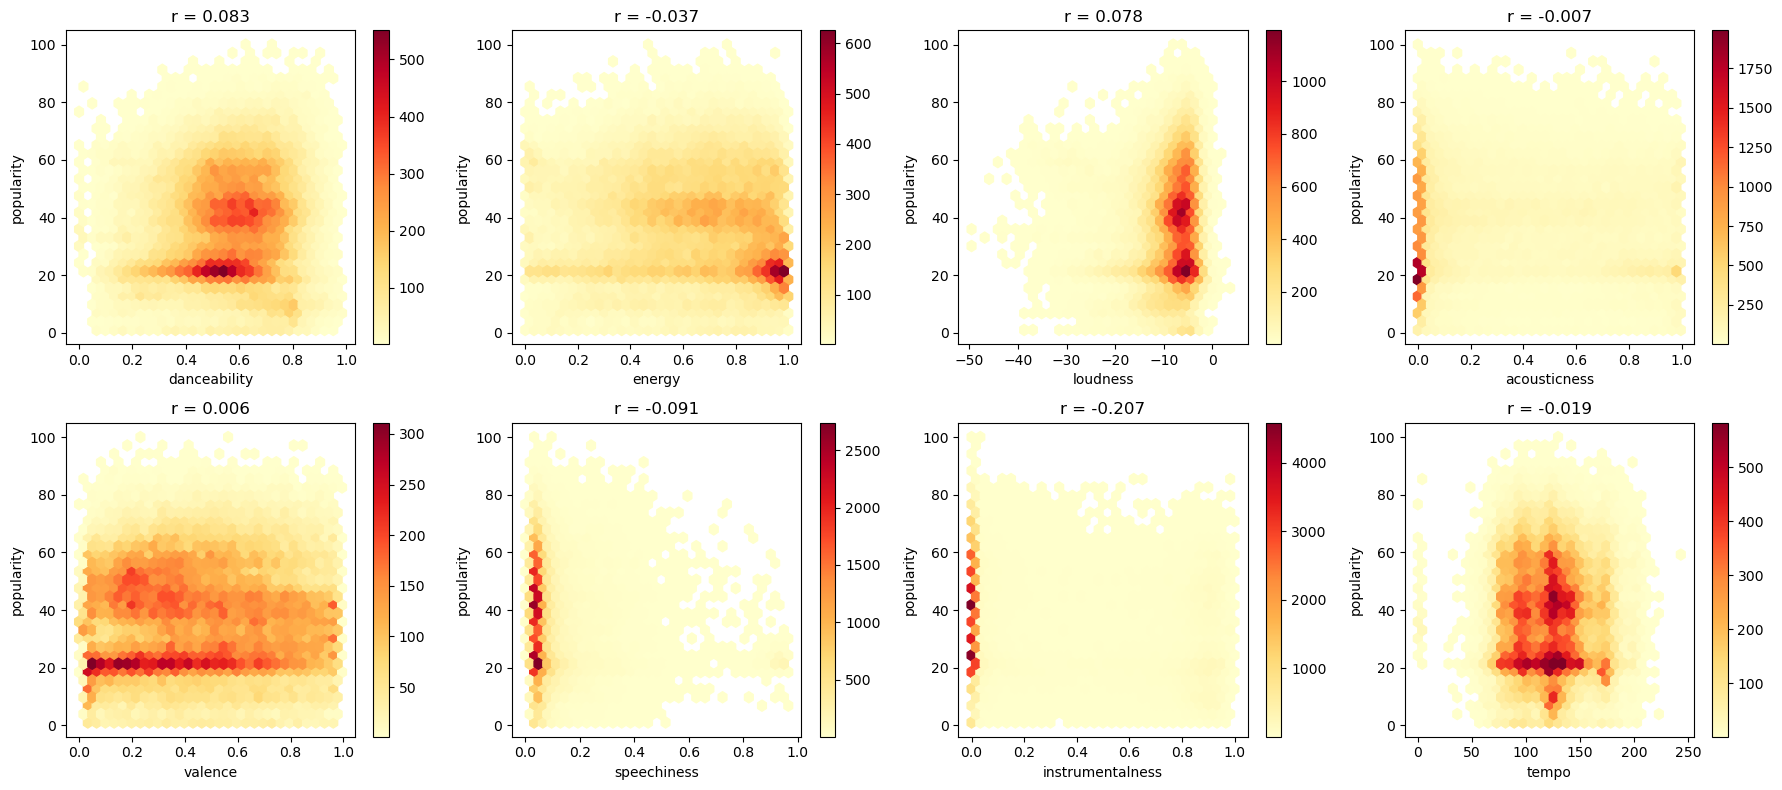

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
features_scatter = ['danceability', 'energy', 'loudness', 'acousticness', 'valence', 'speechiness', 'instrumentalness', 'tempo']

for ax, feat in zip(axes.flat, features_scatter):
    hb = ax.hexbin(df[feat], df['popularity'], gridsize=30, cmap='YlOrRd', mincnt=1)
    ax.set_xlabel(feat)
    ax.set_ylabel('popularity')
    r = df[feat].corr(df['popularity'])
    ax.set_title(f'r = {r:.3f}')
    plt.colorbar(hb, ax=ax)

plt.tight_layout()
plt.show()

Le correlazioni lineari tra le feature audio e `popularity` sono tutte molto basse (< 0.21), confermando che la popolarità di un brano non è linearmente spiegabile da una singola caratteristica audio.

La correlazione più alta in valore assoluto è quella di `instrumentalness` (-0.207): i brani strumentali tendono ad essere meno popolari, probabilmente perché il pubblico mainstream preferisce brani con voce.

`danceability` (0.083) e `loudness` (0.078) mostrano una debole correlazione positiva: i brani più ballabili e più forti tendono ad essere leggermente più popolari.

`speechiness` (-0.091) mostra una correlazione negativa: i brani con alta presenza di parlato (podcast, spoken word) sono meno popolari nel contesto Spotify.

`energy`, `acousticness`, `valence` e `tempo` mostrano correlazioni praticamente nulle (< 0.04), suggerendo che queste feature da sole non sono predittive della popolarità.

I grafici confermano visivamente questo pattern: la distribuzione della popolarità appare sostanzialmente uniforme lungo tutti i valori di ciascuna feature, senza trend lineari evidenti. Questo suggerisce che la popolarità dipende da combinazioni non lineari delle feature.

### 2.5 Relazione tra variabili categoriche e popularity

Analizziamo come la popolarità varia al variare delle feature categoriche del dataset.

/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_39329/4142784674.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_39329/4142784674.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_39329/4142784674.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(ts_data, labels=[str(int(ts)) for ts in ts_values])
/var/folders/98/9v8r_c250c90g9n_qlvzwwlw0000gn/T/ipykernel_39329/4142784674.py:32: MatplotlibDeprecationWarning: The 'labels' parameter o

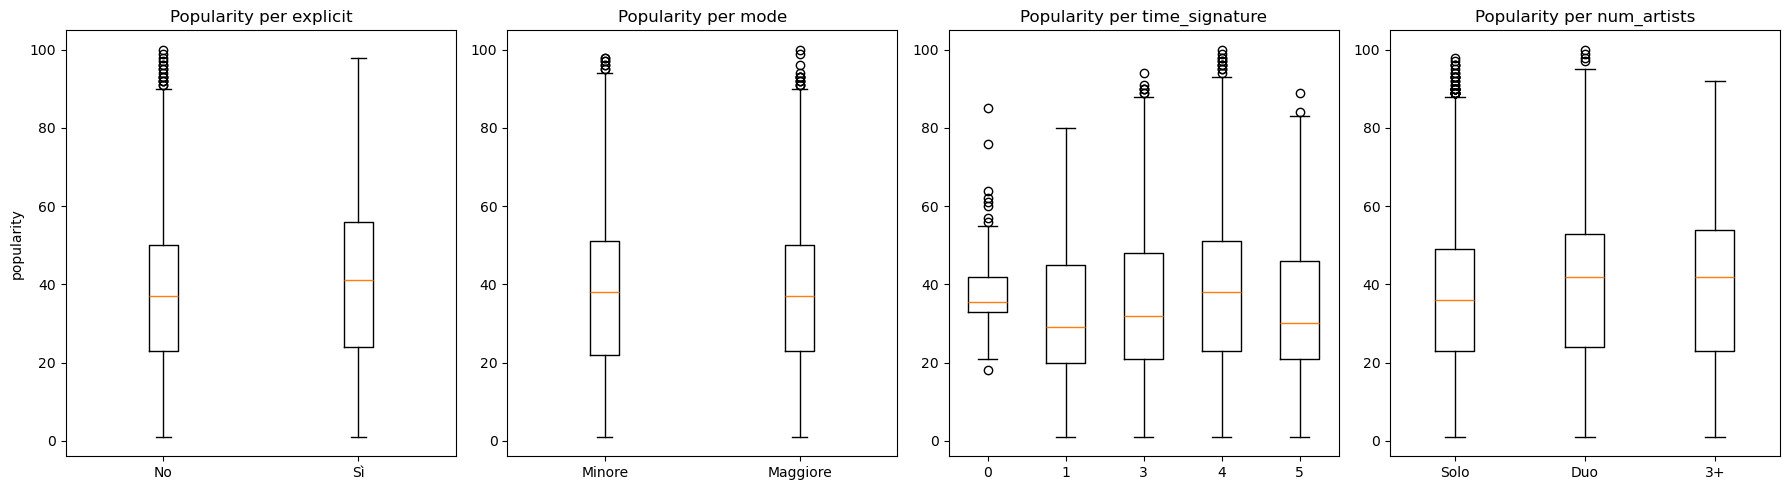

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# explicit
axes[0].boxplot(
    [df[df['explicit'] == False]['popularity'], df[df['explicit'] == True]['popularity']],
    labels=['No', 'Sì']
)
axes[0].set_title('Popularity per explicit')
axes[0].set_ylabel('popularity')

# mode
axes[1].boxplot(
    [df[df['mode'] == 0]['popularity'], df[df['mode'] == 1]['popularity']],
    labels=['Minore', 'Maggiore']
)
axes[1].set_title('Popularity per mode')

# time_signature
ts_values = sorted(df['time_signature'].unique())
ts_data = [df[df['time_signature'] == ts]['popularity'] for ts in ts_values]
axes[2].boxplot(ts_data, labels=[str(int(ts)) for ts in ts_values])
axes[2].set_title('Popularity per time_signature')

# num_artists
na_values = [1, 2, 3]
na_labels = ['Solo', 'Duo', '3+']
na_data = [
    df[df['num_artists'] == 1]['popularity'],
    df[df['num_artists'] == 2]['popularity'],
    df[df['num_artists'] >= 3]['popularity']
]
axes[3].boxplot(na_data, labels=na_labels)
axes[3].set_title('Popularity per num_artists')

plt.tight_layout()
plt.show()

Dai boxplot si osserva che:

- I brani **espliciti** hanno mediana e media di popolarità più alte dei non-espliciti. La differenza è moderata ma consistente.
- La differenza tra brani in tonalità **maggiore** e **minore** è trascurabile: `mode` non sembra essere una feature informativa per la popolarità.
- La popolarità non mostra differenze significative tra le varie time_signature.
- I brani con **più artisti** (collaborazioni) hanno mediana di popolarità più alta dei brani di un singolo artista: le collaborazioni tendono a essere più popolari.

### 2.6 Analisi per genere musicale

In [18]:
genre_stats = (
    df.groupby('track_genre', observed=True)['popularity']
    .agg(['median', 'mean', 'count'])
    .round(2)
)

print("10 generi più popolari:")
print(genre_stats.sort_values('mean', ascending=False).head(10).to_string())

print("\n10 generi meno popolari:")
print(genre_stats.sort_values('mean', ascending=True).head(10).to_string())

10 generi più popolari:
             median   mean  count
track_genre                      
pop            68.0  67.07    472
electro        69.0  63.97    270
edm            63.0  60.76    262
metal          65.0  60.57    361
hip-hop        61.0  59.96    506
house          66.0  59.52    249
k-pop          60.0  59.14    819
pop-film       59.0  58.08    761
alt-rock       60.0  57.91    287
indie-pop      62.0  57.71    336

10 generi meno popolari:
                median   mean  count
track_genre                         
iranian            6.0   6.46    336
romance            7.0   9.35    333
detroit-techno     8.0  11.20    931
chicago-house     10.0  12.34    933
grindcore         14.0  14.66    968
kids              12.0  15.11    921
idm               12.0  15.83    949
honky-tonk        13.0  16.44    825
breakbeat         14.0  19.73    920
tango             19.0  20.28    922


L'analisi per genere rivela differenze molto marcate:

- I generi più popolari hanno popolarità mediana sopra **60**, mentre quelli meno popolari hanno mediana sotto **20**, con uno scarto di oltre **80** punti.
- La variabilità *intra*-genere è comunque elevata: anche i generi mediamente popolari contengono brani a bassa popolarità e viceversa.

### 2.7 Conclusioni dell'analisi dei dati

L'analisi dei dati ha permesso di evidenziare alcuni aspetti chiave del dataset:

- Nessuna feature audio ha un potere predittivo lineare forte.
- Alcune feature sono fortemente correlate tra loro.
- `track_genre` emerge come la variabile più discriminante.
- Nella preparazione dei dati, sarà opportuno rimuovere i brani con valori di feature anomali, come `tempo`, `duration_s`, `loudness`.

## 3. Preparazione dei dati
Creazione di una copia del dataset, rimozione delle feature inutilizzate.

In [19]:
df_model = df.copy()
df_model = df_model.drop(columns=['artists', 'album_name', 'track_name'])

Rimozione dei brani con caratteristiche anomale.

In [20]:
df_model = df_model[(df_model['duration_s'] >= 60) & (df_model['duration_s'] <= 480)]
df_model = df_model[(df_model['loudness'] >= -60) & (df_model['loudness'] <= 0)]
df_model = df_model[(df_model['tempo'] >= 30) & (df_model['tempo'] <= 300)]

Conversione della feature `explicit` da bool a int.

In [21]:
df_model['explicit'] = df_model['explicit'].astype(int)

### Creazione di train e test set
Separazione della variabile target `popularity` dalle feature predittive e suddivisione del dataset in training set (80%) e test set (20%).

In [22]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (59341, 16)
Test set:     (14836, 16)


### Target encoding di `track_genre`

Il dataset contiene 114 generi musicali distinti. Codificarli con `pd.get_dummies` produrrebbe 113 colonne binarie (one-hot encoding). Questo aumenterebbe la dimensionalità del problema da 16 a ~128 feature, rallentando i modelli e riempiendoli di rumore.

È preferibile invece il **target encoding**: ogni genere viene sostituito con la popolarità media dei brani di quel genere, calcolata esclusivamente sul training set per evitare data leakage. Otteniamo così una singola feature numerica che cattura l'informazione *"i brani di questo genere tendono ad avere popolarità X"*.

In [23]:
# Target encoding: sostituisce track_genre con la popolarità media per genere
# calcolata SOLO sul training set per evitare data leakage
genre_mean = y_train.groupby(X_train['track_genre'], observed=True).mean()

X_train['genre_popularity_mean'] = X_train['track_genre'].map(genre_mean)
X_test['genre_popularity_mean'] = X_test['track_genre'].map(genre_mean)

# Rimuovi la colonna categorica originale
X_train = X_train.drop(columns=['track_genre'])
X_test = X_test.drop(columns=['track_genre'])

print(f"Shape dopo target encoding: {X_train.shape}")
print(f"Feature dopo target encoding: {X_train.shape[1]}")
print(X_train.dtypes)
df_model.info(verbose=False, memory_usage="deep")

Shape dopo target encoding: (59341, 16)
Feature dopo target encoding: 16
explicit                    int64
danceability              float64
energy                    float64
key                         int64
loudness                  float64
mode                        int64
speechiness               float64
acousticness              float64
instrumentalness          float64
liveness                  float64
valence                   float64
tempo                     float64
time_signature              int64
duration_s                float64
num_artists                 int64
genre_popularity_mean    category
dtype: object
<class 'pandas.DataFrame'>
Index: 74177 entries, 20001 to 60590
Columns: 17 entries, popularity to num_artists
dtypes: category(1), float64(10), int64(6)
memory usage: 9.7 MB


Trattandosi di un problema di regressione e non di classificazione, non è necessario ricorrere a tecniche di oversampling o undersampling, in quanto non esistono classi sbilanciate da bilanciare.

## 4. Preparazione del modello

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

def print_eval(X, y, model):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y - preds))
    rel_err = mae / y.mean()
    r2 = r2_score(y, preds)
    print(f"Mean squared error:    \t{mse:.3f}")
    print(f"RMSE:                  \t{rmse:.3f}")
    print(f"Mean absolute error:   \t{mae:.3f}")
    print(f"Relative error:        \t{rel_err:.3%}")
    print(f"R-squared coefficient: \t{r2:.3f}")

### Baseline (DummyRegressor)

Prima di addestrare i modelli veri, viene fissato un punto di riferimento. Il `DummyRegressor` con strategia `mean` predice **sempre la media** della popolarità del training set, ignorando completamente qualsiasi feature. Per definizione ha R² = 0: qualunque modello che abbia imparato qualcosa dai dati deve superare questa soglia.

In [25]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

print(f"Il DummyRegressor predice sempre: {dummy.constant_.item():.2f}")
print()
print('Train set')
print_eval(X_train, y_train, dummy)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, dummy)

Il DummyRegressor predice sempre: 37.75

Train set
Mean squared error:    	318.311
RMSE:                  	17.841
Mean absolute error:   	14.883
Relative error:        	39.424%
R-squared coefficient: 	0.000
Test set
Mean squared error:    	314.758
RMSE:                  	17.741
Mean absolute error:   	14.783
Relative error:        	39.202%
R-squared coefficient: 	-0.000


Come atteso, R² = 0 e l'errore è elevato. Questo è il livello minimo da battere: tutti i modelli successivi verranno confrontati con questa soglia per verificare che stiano effettivamente apprendendo informazione dalle feature.

### Regressione lineare

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, linear)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, linear)

Train set
Mean squared error:    	163.042
RMSE:                  	12.769
Mean absolute error:   	9.319
Relative error:        	24.685%
R-squared coefficient: 	0.488
Test set
Mean squared error:    	159.416
RMSE:                  	12.626
Mean absolute error:   	9.191
Relative error:        	24.374%
R-squared coefficient: 	0.494


### Regressione Lasso

In [27]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.05, 0.1, 0.5, 1]}
gs_lasso = GridSearchCV(lasso, grid, cv=5)
gs_lasso.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_lasso)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_lasso)

Train set
Mean squared error:    	163.097
RMSE:                  	12.771
Mean absolute error:   	9.326
Relative error:        	24.705%
R-squared coefficient: 	0.488
Test set
Mean squared error:    	159.384
RMSE:                  	12.625
Mean absolute error:   	9.198
Relative error:        	24.390%
R-squared coefficient: 	0.494


#### Analisi dei coefficienti di Lasso
Il Lasso, grazie alla regolarizzazione L1, azzera i coefficienti delle feature meno rilevanti, effettuando automaticamente una selezione delle variabili più importanti per la predizione.

In [28]:
coef_lasso = pd.Series(
    gs_lasso.best_estimator_.named_steps['lasso'].coef_,
    index=X_train.columns
)

non_zero = coef_lasso[coef_lasso != 0].sort_values()
zero = coef_lasso[coef_lasso == 0]

print(f"\nBest alpha: {gs_lasso.best_params_['lasso__alpha']}")
print("=========================================")
print(f"Feature selezionate: {len(non_zero)} su {len(coef_lasso)}")
print(f"Feature escluse:     {len(zero)} su {len(coef_lasso)}")
print("=========================================")
print("Top 10 coefficienti positivi:")
print(non_zero.tail(10).sort_values(ascending=False).to_string())
print("=========================================")
print("Top 10 coefficienti negativi:")
print(non_zero.head(10).to_string())
print("=========================================")
print("Feature escluse:")
print(zero.index.tolist())



Best alpha: 0.05
Feature selezionate: 15 su 16
Feature escluse:     1 su 16
Top 10 coefficienti positivi:
genre_popularity_mean    12.073523
loudness                  0.452473
explicit                  0.390246
danceability              0.381967
time_signature            0.086155
num_artists              -0.022999
mode                     -0.038425
tempo                    -0.041538
acousticness             -0.218738
duration_s               -0.255399
Top 10 coefficienti negativi:
energy             -0.588731
liveness           -0.437695
speechiness        -0.433609
valence            -0.408373
instrumentalness   -0.352357
duration_s         -0.255399
acousticness       -0.218738
tempo              -0.041538
mode               -0.038425
num_artists        -0.022999
Feature escluse:
['key']


Il GridSearchCV ha selezionato alpha = 0.05, con cui il Lasso mantiene 15 feature su 16, escludendo solo `key`.

Il risultato più evidente è che `genre_popularity_mean` ha un coefficiente dominante (12.19) rispetto a tutte le altre feature. Questo conferma che il genere musicale è di gran lunga la variabile più predittiva della popolarità.

Tra le feature audio, `loudness` ed `explicit` mostrano coefficienti positivi: i brani più forti e con contenuto esplicito tendono ad essere più popolari. `danceability` contribuisce positivamente, confermando la preferenza del pubblico mainstream per brani ballabili.

I coefficienti negativi più alti appartengono a `energy`, `liveness`, `valence` e `speechiness`. Il segno negativo di `energy` può sembrare controintuitivo, ma è spiegabile dal fatto che, una volta controllato il genere, i brani più energetici non sono necessariamente più popolari all'interno della stessa categoria musicale.

La feature esclusa (`key`) conferma quanto emerso nell'EDA: la tonalità non ha influenza lineare sulla popolarità. Anche `tempo` ha un coefficiente prossimo a zero, pur non essendo stato completamente azzerato.

### Regressione Ridge

In [29]:

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.1, 1, 10, 50, 100]}
gs_ridge = GridSearchCV(ridge, grid, cv=5)
gs_ridge.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_ridge)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_ridge)

Train set
Mean squared error:    	163.042
RMSE:                  	12.769
Mean absolute error:   	9.319
Relative error:        	24.686%
R-squared coefficient: 	0.488
Test set
Mean squared error:    	159.416
RMSE:                  	12.626
Mean absolute error:   	9.192
Relative error:        	24.374%
R-squared coefficient: 	0.494


### Elastic Net

In [30]:
from sklearn.linear_model import ElasticNet

elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', ElasticNet())
])
grid = {
    'regr__alpha': [0.1, 0.5, 1],
    'regr__l1_ratio': [0.1, 0.25, 0.5]
}
gs_elasticnet = GridSearchCV(elasticnet, grid, cv=5, scoring='r2')
gs_elasticnet.fit(X_train, y_train)

print('Train set')
print_eval(X_train, y_train, gs_elasticnet)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_elasticnet)

Train set
Mean squared error:    	163.490
RMSE:                  	12.786
Mean absolute error:   	9.446
Relative error:        	25.021%
R-squared coefficient: 	0.486
Test set
Mean squared error:    	159.765
RMSE:                  	12.640
Mean absolute error:   	9.315
Relative error:        	24.700%
R-squared coefficient: 	0.492


### Test Regressione Polinomiale

In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [50, 100, 200, 500, 1000]}
gs_poly = GridSearchCV(poly_ridge, grid, cv=5, scoring='r2', n_jobs=-1)
gs_poly.fit(X_train, y_train)

print(f"Best alpha: {gs_poly.best_params_}")
print('Train set')
print_eval(X_train, y_train, gs_poly)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, gs_poly)

Best alpha: {'ridge__alpha': 200}
Train set
Mean squared error:    	160.359
RMSE:                  	12.663
Mean absolute error:   	9.233
Relative error:        	24.458%
R-squared coefficient: 	0.496
Test set
Mean squared error:    	157.776
RMSE:                  	12.561
Mean absolute error:   	9.145
Relative error:        	24.251%
R-squared coefficient: 	0.499


### XGBoost
I modelli lineari (Linear Regression, Lasso, Ridge, ElasticNet) ottengono tutti R² intorno a 0.49, e la regressione polinomiale non migliora significativamente.

Si procede quindi con XGBoost (Extreme Gradient Boosting), un modello basato su alberi decisionali costruiti in modo sequenziale: ogni albero corregge gli errori del precedente, producendo un modello finale più accurato. A differenza dei modelli lineari, XGBoost è in grado di catturare interazioni complesse tra le feature senza la necessità di crearle esplicitamente.

La ricerca degli iperparametri è effettuata tramite **Randomized Search**, che campiona casualmente le combinazioni dallo spazio dei parametri invece di provarle tutte esaustivamente, approccio più efficiente data la dimensione dello spazio di ricerca.

In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ))
])

param_dist = {
    'xgb__n_estimators':     [300, 500],
    'xgb__max_depth':        [4, 6],
    'xgb__learning_rate':    [0.01, 0.05],
    'xgb__subsample':        [0.7, 0.8],
    'xgb__colsample_bytree': [0.7, 0.8],
    'xgb__reg_alpha':        [0, 0.1, 0.5],
    'xgb__reg_lambda':       [1, 2, 5],
}

rs_xgb = RandomizedSearchCV(
    xgb, param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rs_xgb.fit(X_train, y_train)

print(f"Best params: {rs_xgb.best_params_}")
print('Train set')
print_eval(X_train, y_train, rs_xgb)
print("=========================================")
print('Test set')
print_eval(X_test, y_test, rs_xgb)

Best params: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 2, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 500, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
Train set
Mean squared error:    	117.820
RMSE:                  	10.854
Mean absolute error:   	7.836
Relative error:        	20.756%
R-squared coefficient: 	0.630
Test set
Mean squared error:    	149.137
RMSE:                  	12.212
Mean absolute error:   	8.743
Relative error:        	23.186%
R-squared coefficient: 	0.526


# Test

In [33]:
def predict_popularity(
    danceability=0.5,
    energy=0.5,
    key=0,
    loudness=-10.0,
    mode=1,
    speechiness=0.05,
    acousticness=0.5,
    instrumentalness=0.0,
    liveness=0.1,
    valence=0.5,
    tempo=120.0,
    duration_s=200,
    explicit=0,
    num_artists=1,
    track_genre='pop'
):
    input_dict = {
        'danceability': danceability,
        'energy': energy,
        'key': key,
        'loudness': loudness,
        'mode': mode,
        'speechiness': speechiness,
        'acousticness': acousticness,
        'instrumentalness': instrumentalness,
        'liveness': liveness,
        'valence': valence,
        'tempo': tempo,
        'duration_s': duration_s,
        'explicit': explicit,
        'num_artists': num_artists,
        'track_genre': track_genre
    }
    
    input_df = pd.DataFrame([input_dict])
    
    # Applica target encoding con le stesse medie del training set
    input_df['genre_popularity_mean'] = input_df['track_genre'].map(genre_mean)
    
    # Gestisci generi non visti nel training set
    input_df['genre_popularity_mean'] = input_df['genre_popularity_mean'].fillna(genre_mean.mean())
    
    # Rimuovi la colonna categorica
    input_df = input_df.drop(columns=['track_genre'])
    
    # Allinea le colonne al training set
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)
    
    pred = rs_xgb.predict(input_df)[0]
    pred = np.clip(pred, 0, 100)
    
    print(f"Popolarità stimata: {pred:.1f} / 100")
    if pred >= 60:
        print("🟢 Brano probabilmente popolare")
    elif pred >= 40:
        print("🟡 Brano mediamente popolare")
    else:
        print("🔴 Brano probabilmente di nicchia")

In [34]:
predict_popularity(
    danceability=0.8,
    energy=0.9,
    loudness=-5.0,
    valence=0.9,
    tempo=140.0,
    track_genre='pop',
    explicit=1
)

predict_popularity(
    danceability=0.3,
    energy=0.4,
    instrumentalness=0.9,
    track_genre='classical'
)

Popolarità stimata: 65.9 / 100
🟢 Brano probabilmente popolare
Popolarità stimata: 27.6 / 100
🔴 Brano probabilmente di nicchia


# Interpretazione della conoscenza appresa dal modello

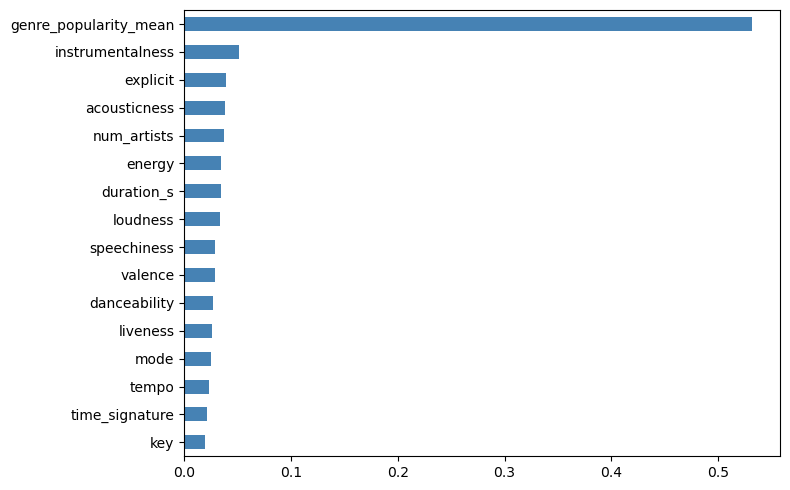

In [35]:
importances = pd.Series(
    rs_xgb.best_estimator_.named_steps['xgb'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Le feature importances di XGBoost confermano in modo netto che `genre_popularity_mean` è di gran lunga la feature più rilevante, con un'importanza (~0.55) circa 10 volte superiore a qualsiasi altra variabile. Il genere musicale domina la predizione della popolarità.

Al secondo posto troviamo `explicit`, coerente con quanto osservato nei boxplot dell'EDA: i brani con contenuto esplicito tendono ad essere più popolari. Seguono `instrumentalness` e `num_artists`, con importanza simile ma nettamente inferiore al genere.

Le restanti feature audio (`acousticness`, `loudness`, `energy`, `valence`, `danceability`, ecc.) contribuiscono in misura marginale e pressoché uguale tra loro. `mode`, `key` e `time_signature` sono le meno rilevanti, confermando quanto già emerso dall'analisi Lasso: le caratteristiche musicali teoriche (tonalità, modo, metro) non influenzano la popolarità.

Questo risultato evidenzia un limite intrinseco del problema: la popolarità è determinata principalmente dal genere di appartenenza e dal tipo di contenuto, mentre le sfumature delle feature audio hanno un ruolo secondario.

# Esportazione del modello
Si esporta il modello migliore (XGBoost) tramite `pickle`, insieme alla mappatura del target encoding (`genre_mean`) e alla lista delle colonne usate in addestramento. Questi tre elementi sono necessari e sufficienti per poter effettuare predizioni su nuovi dati, ad esempio tramite l'applicazione web realizzata assieme al progetto.

In [36]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump({
        'model': rs_xgb.best_estimator_,
        'genre_mean': genre_mean,
        'columns': X_train.columns.tolist()
    }, f)

## Conclusioni

conclusioni